## Variável Quantitativa Continua — Tempo de Ciclo

Este notebook atende ao critério **"Tabela com a distribuição de frequências da variável qualitativa e representação gráfica"** e ao critério **"Medidas resumo para a variável quantitativa"** da rubrica da sprint 1.

**Base de dados:** `Eficiencia Operacional em Linhas de Producao.xlsx` (n = 1000 linhas de produção)

**Variável analisada:** `Tempo_ciclo` — quantitativa **continua**.

#### 1. Importar as bibliotecas Pandas e Math

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math

#### 2. Definir a variável "arrquivo" pelo nome da planilha e a variável "coluna" com a variável "coluna" como a variável de analise neste caso Tempo_ciclo

In [69]:
arquivo = 'refs/Eficiencia Operacional em Linhas de Producao.xlsx'
coluna = 'Tempo_Ciclo_s'

#### 3. Importando e lendo a base de dados da planilha via script

In [70]:
df = pd.read_excel(arquivo)
df

,Nivel_Automacao,Tempo_Ciclo_s,Unidades_Produzidas
0,Alta,52.42,523
1,Baixa,43.03,643
2,Média,58.33,421
3,Baixa,55.95,495
4,Alta,36.54,832
...,...,...,...
995,Baixa,54.31,446
996,Média,49.62,601
997,Alta,51.04,597
998,Média,57.56,400


#### 4. Montando a tabela de classes — encontrando os parâmetros

##### 4.1 Encontrando os parâmetros

In [71]:
# Encontrando os valores máximos e mínimos dos dados
valormin = df[coluna].min()
valormax = df[coluna].max()
delta = valormax - valormin

# Encontrando a quantidade unitária de amostras
n = df[coluna].count()

# Encontrando a quantidade de classes
# OBS: o comando math.ceil serve para realizar um arredondamento para cima
# do valor calculado dentro do parâmetro dele, neste caso a raiz de N
k = math.ceil(math.sqrt(n))

# Calculando amplitude de cada classe
amplitude = round(delta/k,2)

print(f'Parâmetro da base de dados calculados'
      f'\nValor máximo de tempo de ciclo dos dados: {valormax}'
      f'\nValor Mínime de tempo de ciclo dos dados: {valormin}'
      f'\nDiferença entre máximo e mínimo: {delta}'
      f'\nQuantidade unitária de amostras encontradas: {n}'
      f'\nQuantidade de classes calculadas: {k}'
      f'\nAmplitude calculada por classe: {amplitude}')


Parâmetro da base de dados calculados
Valor máximo de tempo de ciclo dos dados: 75.63
Valor Mínime de tempo de ciclo dos dados: 24.77
Diferença entre máximo e mínimo: 50.86
Quantidade unitária de amostras encontradas: 1000
Quantidade de classes calculadas: 32
Amplitude calculada por classe: 1.59


##### 4.2 Montando as classes

In [72]:
# Calculando o limite inferior das classes
# OBS: o comando math.floor serve para arredondar o valor
# para baixo, ou seja, no caso do valormin sendo 24.77,
# limite_inferior será 24
limite_inferior = math.floor(valormin)

# Criando a array de classes de maneira dinâmica
classes = []
i = 0
while True:
    # calcula o limite fazendo o valor de limite inferior + i X amplitude
    # e por fim arredonda para 2 dígitos o valor obtido
    limite = round(limite_inferior + i * amplitude, 2)

    # Pega aquele novo limite calculado e adiciona como um novo elemento na
    # array de classes
    classes.append(limite)

    # Se o limite for maior que o valor máximo dos dados ele sai do loop
    # e printa as classes
    if limite > valormax:
        break

    # Soma 1 no valor de i
    i += 1

print(classes)
print('Quantidade de classes geradas: ',len(classes)-1)


[24.0, 25.59, 27.18, 28.77, 30.36, 31.95, 33.54, 35.13, 36.72, 38.31, 39.9, 41.49, 43.08, 44.67, 46.26, 47.85, 49.44, 51.03, 52.62, 54.21, 55.8, 57.39, 58.98, 60.57, 62.16, 63.75, 65.34, 66.93, 68.52, 70.11, 71.7, 73.29, 74.88, 76.47]
Quantidade de classes geradas:  33


#### 5. Encontrando a frequência absoluta e relativa dos dados de tempo de ciclo

In [73]:
# Calculando a frequência absoluta da coluna tempo de ciclo da base de dados por classe
frequencia = pd.cut(x=df[coluna], bins=classes, include_lowest=True, right=False).value_counts()
frequencia = frequencia.sort_index()

# Calculando frequência relativa (%) da coluna tempo de ciclo da base de dados por classe
frequencia_relativa = round(pd.cut(x=df[coluna], bins=classes, include_lowest=True, right=False).value_counts(normalize=True) * 100, 2)
frequencia_relativa = frequencia_relativa.sort_index()

# Calculando a frequência absoluta acumulada da coluna tempo de ciclo da base de dados por classe
# OBS: o comando cumsum(), realiza exatamente a mesma coisa que o np.cumsum só que sem a necessidade
# de incrementar a biblioteca numpy
frequencia_acumulada = frequencia.cumsum()

# Calculando a frequência relativa acumulada da coluna tempo de ciclo da base de dados por classe
# OBS: o comando cumsum(), realiza exatamente a mesma coisa que o np.cumsum só que sem a necessidade
# de incrementar a biblioteca numpy
frequencia_relativa_acumulada = frequencia_relativa.cumsum()

#### 6. Montando a tabela

In [74]:
dist_freq = pd.DataFrame({
    'Frequência Absoluta': frequencia,
    'Frequência Relativa (%)': frequencia_relativa,
    'Frequência Absoluta Acumulada': frequencia_acumulada,
    'Frequência Relativa Acumulada': frequencia_relativa_acumulada,
})

dist_freq = dist_freq.reset_index()

dist_freq.columns= [
    'Classes de Tempo de Ciclo (s)',
    'Frequência Absoluta','Frequência Relativa',
    'Frequência Absoluta Acumulada',
    'Frequência Relativa Acumulada (%)'
]

dist_freq['Classes de Tempo de Ciclo (s)'] = dist_freq['Classes de Tempo de Ciclo (s)'].astype(str)

print(f'      Variável: {coluna} (segundos)')
print('      *Limites superiores do intervalo de classes incluídos')

dist_freq

      Variável: Tempo_Ciclo_s (segundos)
      *Limites superiores do intervalo de classes incluídos


,Classes de Tempo de Ciclo (s),Frequência Absoluta,Frequência Relativa,Frequência Absoluta Acumulada,Frequência Relativa Acumulada (%)
0,"[24.0, 25.59)",1,0.1,1,0.1
1,"[25.59, 27.18)",6,0.6,7,0.7
2,"[27.18, 28.77)",15,1.5,22,2.2
3,"[28.77, 30.36)",24,2.4,46,4.6
4,"[30.36, 31.95)",33,3.3,79,7.9
5,"[31.95, 33.54)",70,7.0,149,14.9
6,"[33.54, 35.13)",54,5.4,203,20.3
7,"[35.13, 36.72)",72,7.2,275,27.5
8,"[36.72, 38.31)",65,6.5,340,34.0
9,"[38.31, 39.9)",66,6.6,406,40.6


#### 7. Construindo os gráficos para demonstração

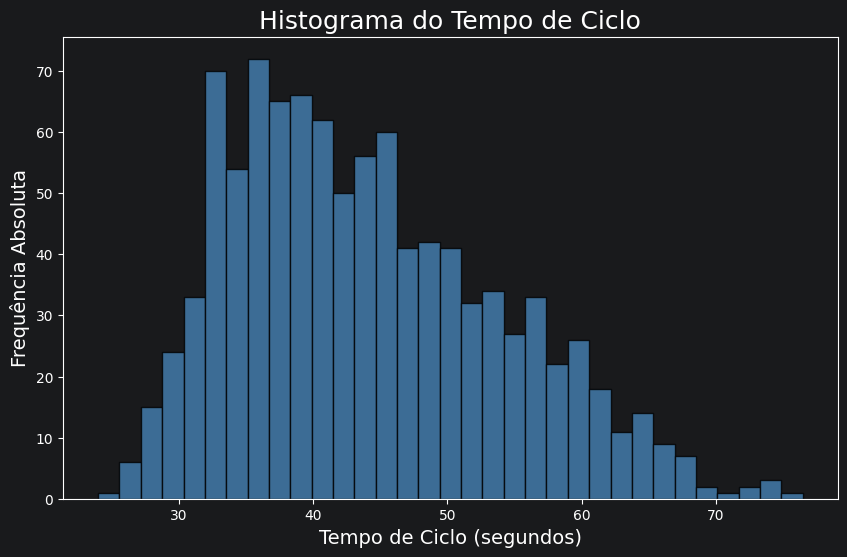

In [75]:
# 7.1. Construindo o Histograma da variável Tempo de Ciclo
plt.figure(figsize=(10,6))

plt.hist(df[coluna], bins=classes, rwidth=1, color='steelblue', alpha=0.8, edgecolor='black')

# Define o título e descrição dos eixos do gráfico e seus respectivos tamanhos de cada texto
plt.title('Histograma do Tempo de Ciclo', fontsize=18)
plt.xlabel('Tempo de Ciclo (segundos)', fontsize=14)
plt.ylabel('Frequência Absoluta', fontsize=14)
plt.tick_params(labelsize=10)

# Imprime o gráfico na tela
plt.show()

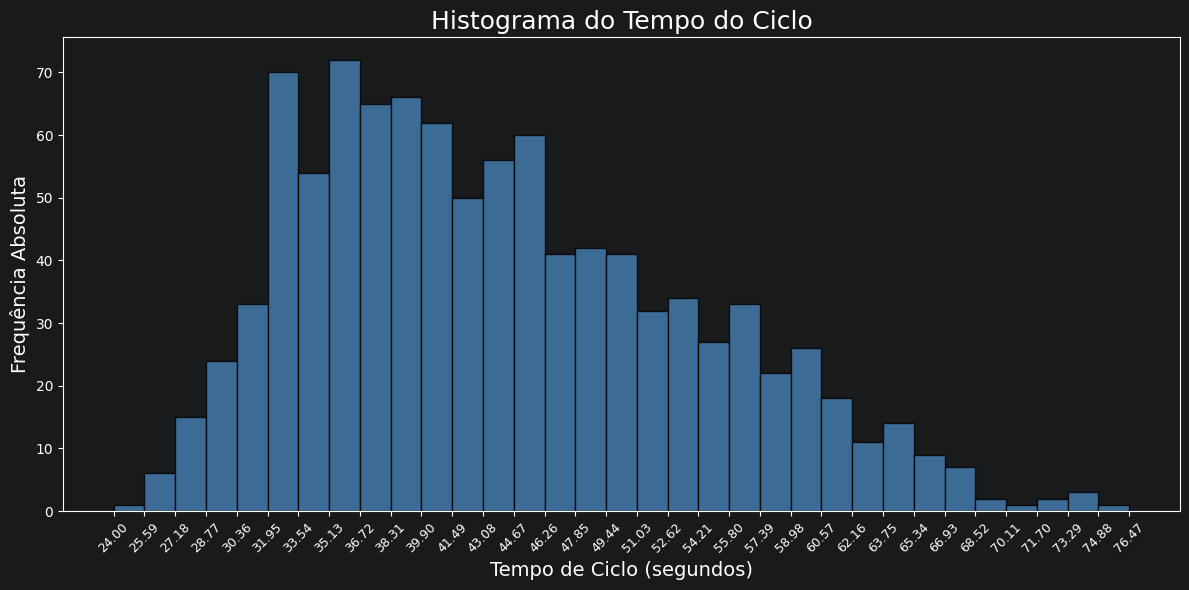

In [76]:
# Construindo o histograma com os limites das classas marcados no eixo X
plt.figure(figsize=(12,6))

plt.hist(df[coluna], bins=classes, rwidth=1, color='steelblue', alpha=0.8, edgecolor='black')

# Define o título e descrição dos eixos do gráfico e seus respectivos tamanhos
plt.title('Histograma do Tempo do Ciclo', fontsize=18)
plt.xlabel('Tempo de Ciclo (segundos)', fontsize=14)
plt.ylabel('Frequência Absoluta', fontsize=14)
plt.xticks(classes, rotation=45, fontsize=9)

# Imprime o gráfico na tela
plt.tight_layout()
plt.show()

#### 8. Calculando e analisando métricas estatísticas

In [81]:
# Definindo e calculando as métricas de média, mediana e moda
# OBS: os comandos e suas descrições e ações:
# mean -> Calcula a média aritmédica dos valores
media = round(df[coluna].mean(), 2)

# median -> Calcula a mediana dos dados
mediana = round(df[coluna].median(), 2)

# mode -> Calcula e encontra a moda dos dados
moda = df[coluna].mode()[0]

# dist_freq['Frequência Absoluta'].idxmax() -> Encontra qual que é a classe modal dos dados
# Já o dest_freq.loc é para localizar dentro de dist_freq
linha_modal = dist_freq.loc[dist_freq['Frequência Absoluta'].idxmax()]
classe_modal = linha_modal['Classes de Tempo de Ciclo (s)']

print(f'Média: {media} segundos')
print(f'Mediana: {mediana} segundos')
print(f'Moda: {moda} segundos')
print(f'Classe modal: {classe_modal} segundos (frequência = {linha_modal["Frequência Absoluta"]})')


Média: 44.03 segundos
Mediana: 42.39 segundos
Moda: 45.77 segundos
Classe modal: [35.13, 36.72) segundos (frequência = 72)


#### 9. Conclusão

**Média (44,03 segundos):** em média, um ciclo de produção da linha leva aproximadamente 44 segundos para ser concluído.

**Mediana (42,39 segundos):** metade dos ciclos de produção observado foi concluído em até 42,39 segundos, a outra metade demandou mais tempo do que isto.

**Moda (45,77 segundos) e classe modal ([35,13; 36,72) segundos):** o valor de 45,77 segundos foi o tempo de ciclo que mais se repetiu de maneira unitária ou seja a moda dos dados. Entretanto a **classe modal** (o intervalo de tempos de ciclo mais frequente), foi de [35,13; 36,72) segundos, tendo 72 ocorrências em todo volume de dados, ou seja, isso significa que 7,2% de todos os dados estão dentro deste intervalo. No fim das constas isso indica que a faixa de duração mais comum da linha de produção está neste intervalo ao invés de no valor unitário da moda.

**Conclusão:** como o valor da média é ligeiramente maior que a mediana, isso mostra que a distribuição do tempo de ciclo apresenta uma leva assimetria à direita, isso evidenciando que existem alguns ciclos com duração acima da média que fazem com que "puxam"/sobre o valor da métrica, enquanto a maior concentração dos ciclos ocorre no intervalo modal, no qual tem valores bem abaixo da média e mediana.